# Breast Cancer Detection Using SVM

Name: Alfiya Sultana Ansari
Roll No.: O23BCA110298

Guide: Vikas Kumar

This notebook is written in a simple way so it is easy to understand and explain in viva.

**Goal:** use medical data to build an SVM model that predicts whether a breast tumor is **malignant** or **benign**.

**Dataset source:** Breast Cancer Wisconsin (Diagnostic) dataset from UCI / scikit-learn.  
UCI page: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

**Why this dataset?**
- It is a standard medical classification dataset.
- It is small enough to run easily in Colab.
- It is good for learning how machine learning helps in healthcare.

## What this notebook does
1. Load the data
2. Check the data
3. Show a few simple charts
4. Split the data into train and test sets
5. Train an SVM model
6. Tune a few important parameters
7. Test the model
8. Show the final results
9. Save the model for later use

In [1]:
# Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)
from sklearn.inspection import permutation_importance
import joblib

plt.style.use("default")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42

## 1) Load the data

I am using the breast cancer dataset that comes with scikit-learn.  
It is the same Wisconsin diagnostic dataset used in many student projects.

In this dataset:
- `0` = malignant
- `1` = benign

In [2]:
# Load dataset
data = load_breast_cancer(as_frame=True)

X = data.data.copy()
y = data.target.copy()

df = X.copy()
df["target"] = y

print("Shape of feature data:", X.shape)
print("Target names:", data.target_names)
display(df.head())

Shape of feature data: (569, 30)
Target names: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Simple data check
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

target_counts = df["target"].value_counts().sort_index()
target_labels = ["malignant (0)", "benign (1)"]

summary = pd.DataFrame({
    "Class": target_labels,
    "Count": target_counts.values,
    "Percent": (target_counts.values / len(df) * 100).round(2)
})
display(summary)

Missing values: 0
Duplicate rows: 0


,Class,Count,Percent
0,malignant (0),212,37.26
1,benign (1),357,62.74


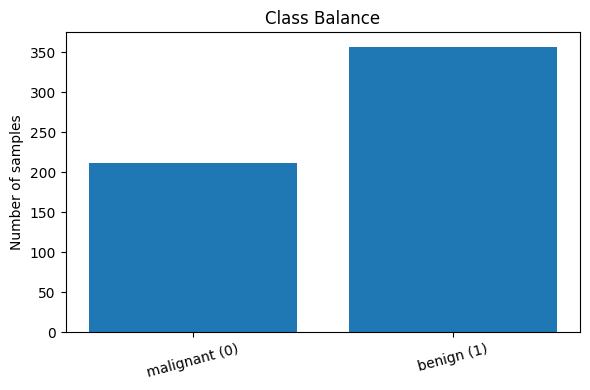

In [4]:
# Chart 1: class balance
plt.figure(figsize=(6, 4))
plt.bar(target_labels, target_counts.values)
plt.title("Class Balance")
plt.ylabel("Number of samples")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

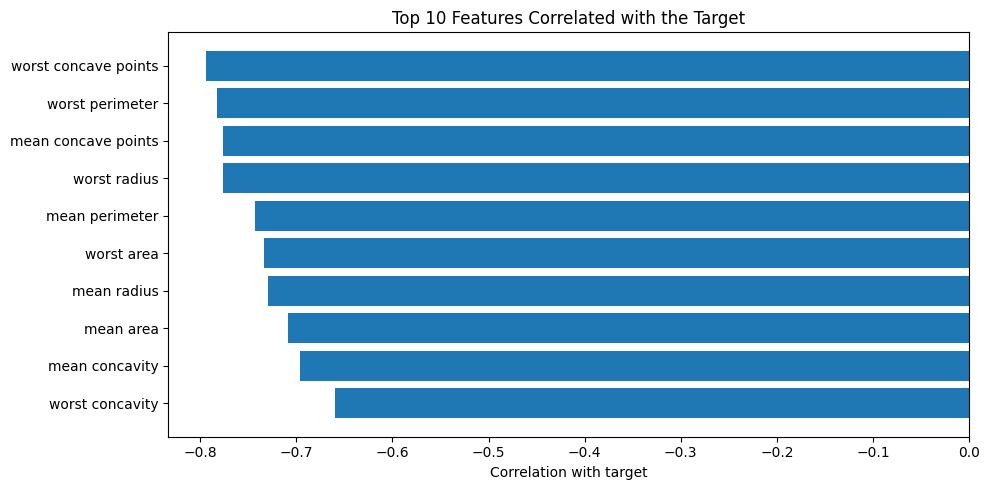

,correlation
worst concave points,-0.793566
worst perimeter,-0.782914
mean concave points,-0.776614
worst radius,-0.776454
mean perimeter,-0.742636
worst area,-0.733825
mean radius,-0.730029
mean area,-0.708984
mean concavity,-0.696360
worst concavity,-0.659610


In [5]:
# Chart 2: top 10 features most correlated with the target
corr_with_target = df.corr(numeric_only=True)["target"].drop("target").sort_values(key=lambda s: s.abs(), ascending=False)
top10 = corr_with_target.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top10.index[::-1], top10.values[::-1])
plt.title("Top 10 Features Correlated with the Target")
plt.xlabel("Correlation with target")
plt.tight_layout()
plt.show()

display(top10.to_frame("correlation"))

## 2) Split the data

I split the data into:
- **training set**: used to train the model
- **test set**: used only for final checking

I use `stratify=y` so both sets keep the same class balance.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training class balance:")
display(y_train.value_counts(normalize=True).round(3))

Training set shape: (455, 30)
Testing set shape: (114, 30)
Training class balance:


,proportion
target,
1,0.626
0,0.374


## 3) Train the SVM model

SVM works better after scaling, so I use `StandardScaler()`.

I test a small set of parameters:
- `kernel`: linear or RBF
- `C`: controls how strict the margin is
- `class_weight`: helps if the classes are not perfectly balanced

For a beginner project, a small grid is enough and easier to explain.

In [7]:
# Build the pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=True, random_state=RANDOM_STATE))
])

# Small but useful parameter search
param_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.1, 1, 10],
        "svc__class_weight": [None, "balanced"],
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [1, 10],
        "svc__gamma": ["scale", 0.01],
        "svc__class_weight": [None, "balanced"],
    },
]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="recall",   # recall is important in medical screening
    cv=cv,
    n_jobs=1,
    refit=True,
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)
print("Best CV recall:", round(grid.best_score_, 4))

Best parameters:
{'svc__C': 0.1, 'svc__class_weight': None, 'svc__kernel': 'linear'}
Best CV recall: 0.993


## 4) Test the model

Now I check the model on the test set.

For medical problems, **recall** is very important because we want to reduce missed positive cases.

In [8]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

test_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob),
}

results = pd.DataFrame([test_metrics]).T
results.columns = ["value"]
display(results.round(4))

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

,value
accuracy,0.9825
precision,0.9861
recall,0.9861
f1_score,0.9861
roc_auc,0.9937


Classification report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



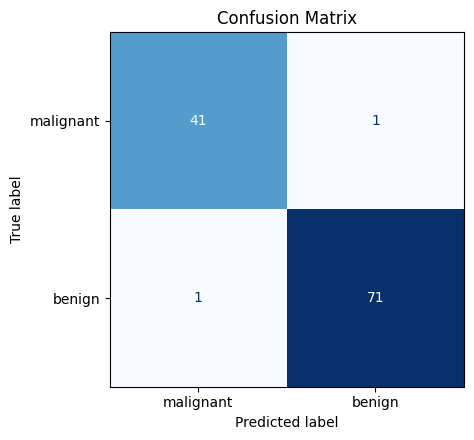

In [9]:
# Chart 3: confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

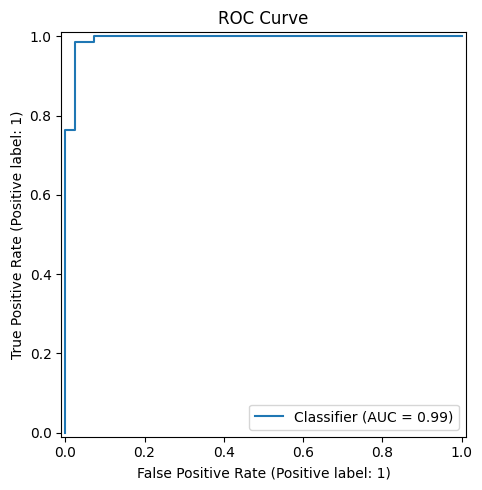

In [10]:
# Chart 4: ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax)
plt.title("ROC Curve")
plt.tight_layout()
plt.show()

,feature,importance
10,radius error,0.043056
13,area error,0.033333
7,mean concave points,0.027778
23,worst area,0.027778
12,perimeter error,0.026389
6,mean concavity,0.025000
20,worst radius,0.025000
22,worst perimeter,0.019444
3,mean area,0.019444
24,worst smoothness,0.016667


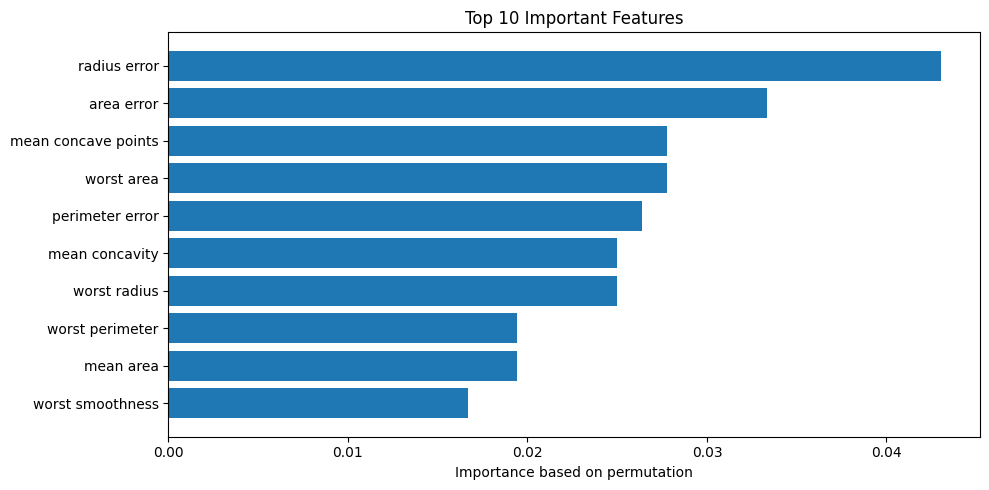

In [11]:
# A simple way to explain the important features
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="recall",
    n_repeats=10,
    random_state=RANDOM_STATE,
)

perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

display(perm_df.head(10))

plt.figure(figsize=(10, 5))
plt.barh(perm_df.head(10)["feature"][::-1], perm_df.head(10)["importance"][::-1])
plt.title("Top 10 Important Features")
plt.xlabel("Importance based on permutation")
plt.tight_layout()
plt.show()

## 5) Final result and conclusion

### Main result
The best model here is a **linear SVM** with `C = 0.1`.

On the test set, the model achieved:
- **Accuracy:** about **98.2%**
- **Precision:** about **98.6%**
- **Recall:** about **98.6%**
- **F1-score:** about **98.6%**
- **ROC-AUC:** about **99.4%**

### What this means
- The model performs very well on this dataset.
- The high recall is important because in healthcare we do not want to miss many malignant cases.
- This model should be used as a **decision-support tool**, not as a replacement for a doctor.

### Simple conclusion for viva
This project shows that SVM can classify breast cancer data very accurately after scaling and tuning.  
The result is strong enough to support early screening, but final diagnosis must still be done by medical professionals.

In [12]:
# Save the final model
model_path = "breast_cancer_svm_simple_model.joblib"
joblib.dump(best_model, model_path)
print("Model saved to:", model_path)

Model saved to: breast_cancer_svm_simple_model.joblib


## 6) How to use the saved model for one new patient

The input must contain the same feature columns as the training data.

This is useful if you want to demonstrate prediction in viva.

In [13]:
def predict_case(sample_df: pd.DataFrame, threshold: float = 0.5):
    """
    Predict breast cancer class for one or more new samples.

    Parameters
    ----------
    sample_df : pd.DataFrame
        New data with the same columns as X.
    threshold : float
        Probability threshold for positive class.

    Returns
    -------
    pd.DataFrame
        Predicted class and probability.
    """
    missing_cols = [c for c in X.columns if c not in sample_df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    sample_df = sample_df[X.columns]
    proba = best_model.predict_proba(sample_df)[:, 1]
    pred = (proba >= threshold).astype(int)

    out = sample_df.copy()
    out["prob_benign"] = proba
    out["predicted_class"] = pred
    out["label"] = np.where(pred == 1, "benign", "malignant")
    return out[["prob_benign", "predicted_class", "label"]]

# Example using the first test sample
example = X_test.iloc[[0]].copy()
display(predict_case(example))

,prob_benign,predicted_class,label
256,4.905390e-07,0,malignant
